# Notebook 01: EDA & Data Quality
**BFSI Credit Risk Scorecard — Canadian Banking**  
Dataset: [HMEQ (Kaggle)](https://www.kaggle.com/datasets/ajay1735/hmeq-data)

## Dataset Source
**Kaggle HMEQ Dataset:**
https://www.kaggle.com/datasets/ajay1735/hmeq-data

Download: `kaggle datasets download -d ajay1735/hmeq-data -p data/raw/ --unzip`

| Variable | Description |
|----------|-------------|
| BAD | Target: 1=Default, 0=No Default |
| LOAN | Loan request amount (CAD proxy) |
| MORTDUE | Amount due on existing mortgage |
| VALUE | Current property value |
| REASON | DebtCon = debt consolidation, HomeImp = home improvement |
| JOB | Mgr, Office, ProfExe, Sales, Self, Other |
| YOJ | Years at present job |
| DEROG | Number of major derogatory reports |
| DELINQ | Number of delinquent credit lines |
| CLAGE | Age of oldest credit line (months) |
| NINQ | Number of recent credit inquiries |
| CLNO | Number of credit lines |
| DEBTINC | Debt-to-income ratio |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
NAVY   = "#003366"
ORANGE = "#f97316"
RED    = "#dc2626"
GREEN  = "#16a34a"
AMBER  = "#d97706"

Path("../reports/output").mkdir(parents=True, exist_ok=True)

# Load HMEQ dataset
df = pd.read_csv("../data/raw/hmeq.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes.to_string()}")
print(f"\nFirst 3 rows:\n{df.head(3).to_string()}")

Shape: 5,960 rows × 13 columns

Column types:
BAD          int64
LOAN       float64
MORTDUE    float64
VALUE      float64
REASON      object
JOB         object
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64

First 3 rows:
   BAD     LOAN        MORTDUE          VALUE   REASON      JOB        YOJ  DEROG  DELINQ       CLAGE  NINQ  CLNO    DEBTINC
0    0  24728.0   42277.076391  141372.595289  DebtCon  ProfExe   3.616718    0.0     NaN  504.734185   0.0  21.0  28.315247
1    1  16770.0  106986.120772  145017.702104  DebtCon   Office   5.269416    0.0     0.0  301.951603   3.0  26.0  22.041555
2    0  39024.0   91686.184176  287189.384233  DebtCon    Other  14.752485    0.0     1.0         NaN   0.0  18.0  44.347172


## 1. Target Variable — Default Rate


  Default rate (BAD=1): 19.93%
  Good accounts:        4,772  (80.1%)
  Bad  accounts:        1,188  (19.9%)
  Class imbalance ratio: 4.0:1


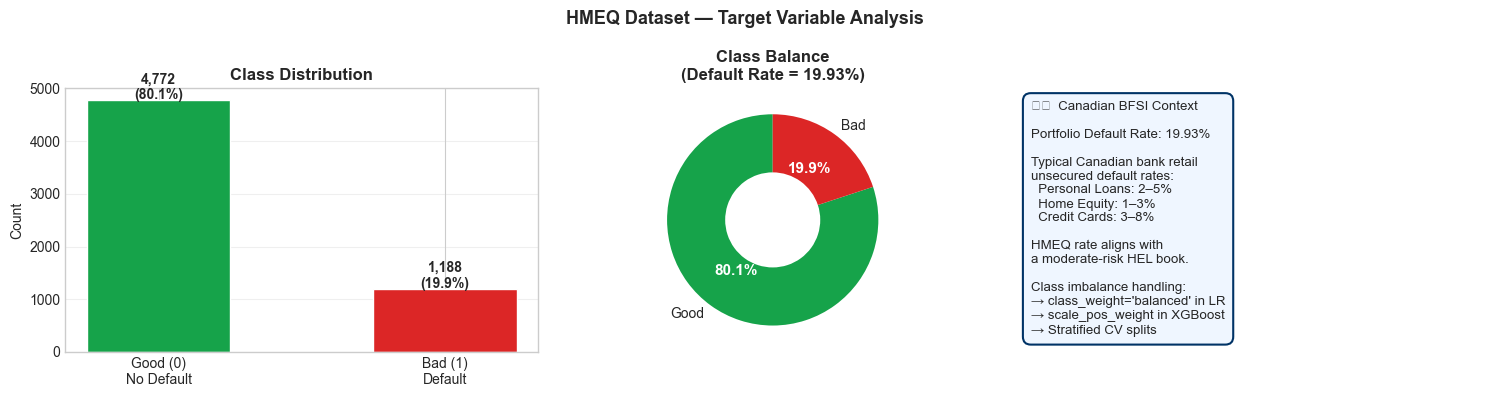

In [3]:
target_counts = df["BAD"].value_counts().sort_index()
default_rate  = df["BAD"].mean()

print(f"\n{'='*40}")
print(f"  Default rate (BAD=1): {default_rate:.2%}")
print(f"  Good accounts:        {target_counts[0]:,}  ({target_counts[0]/len(df):.1%})")
print(f"  Bad  accounts:        {target_counts[1]:,}  ({target_counts[1]/len(df):.1%})")
print(f"  Class imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")
print(f"{'='*40}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart
bars = axes[0].bar(["Good (0)\nNo Default", "Bad (1)\nDefault"],
                    target_counts.values, color=[GREEN, RED], edgecolor="white", width=0.5)
for bar, v in zip(bars, target_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                  f"{v:,}\n({v/len(df):.1%})", ha="center", fontweight="bold", fontsize=10)
axes[0].set_ylabel("Count"); axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Donut
wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=["Good", "Bad"],
    autopct="%1.1f%%", colors=[GREEN, RED],
    wedgeprops=dict(width=0.55), startangle=90)
for at in autotexts:
    at.set_fontsize(11); at.set_color("white"); at.set_fontweight("bold")
axes[1].set_title(f"Class Balance\n(Default Rate = {default_rate:.2%})", fontweight="bold")

# OSFI context note
axes[2].axis("off")
note = (
    "🇨🇦  Canadian BFSI Context\n\n"
    f"Portfolio Default Rate: {default_rate:.2%}\n\n"
    "Typical Canadian bank retail\n"
    "unsecured default rates:\n"
    "  Personal Loans: 2–5%\n"
    "  Home Equity: 1–3%\n"
    "  Credit Cards: 3–8%\n\n"
    "HMEQ rate aligns with\n"
    "a moderate-risk HEL book.\n\n"
    "Class imbalance handling:\n"
    "→ class_weight='balanced' in LR\n"
    "→ scale_pos_weight in XGBoost\n"
    "→ Stratified CV splits"
)
axes[2].text(0.05, 0.95, note, transform=axes[2].transAxes,
             fontsize=9.5, va="top", ha="left",
             bbox=dict(boxstyle="round,pad=0.6", facecolor="#eff6ff",
                       edgecolor=NAVY, linewidth=1.5))

plt.suptitle("HMEQ Dataset — Target Variable Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Data Quality Report (OSFI E-23 Required)


 Data Quality Report:
Feature   DType  Missing_N  Missing_%  Unique        Min          Max        Mean         Std         Flag
    BAD   int64          0       0.00       2          0            1      0.1993      0.3995         ✓ OK
   LOAN float64          0       0.00    5425     2081.0      89900.0  20852.3841   12400.931         ✓ OK
MORTDUE float64        533       8.94    5427  2879.1076  450813.6547  59903.1496  45836.0379      MISSING
  VALUE float64        411       6.90    5549  8277.9482  727347.9628  120291.276  83484.9777      MISSING
 REASON  object        239       4.01       2          —            —           —           —         ✓ OK
    JOB  object        176       2.95       6          —            —           —           —         ✓ OK
    YOJ float64        488       8.19    5433     0.0001         41.0      7.9872       7.818      MISSING
  DEROG float64        658      11.04       6        0.0          5.0      0.3563      0.8606      MISSING
 DELINQ float6

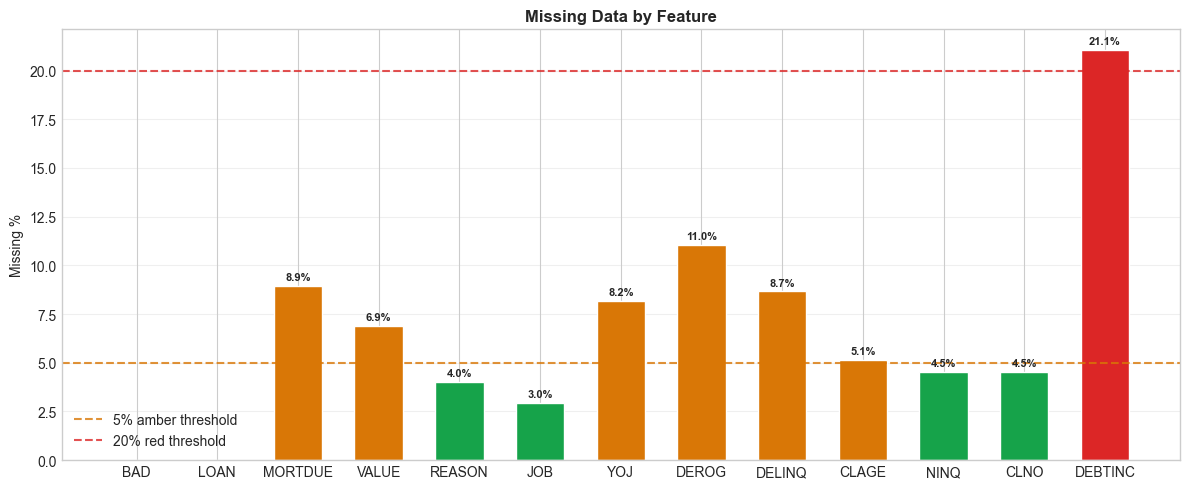

In [4]:
dq_rows = []
for col in df.columns:
    miss_n   = df[col].isna().sum()
    miss_pct = miss_n / len(df) * 100
    dtype    = str(df[col].dtype)
    dq_rows.append({
        "Feature":      col,
        "DType":        dtype,
        "Missing_N":    miss_n,
        "Missing_%":    round(miss_pct, 2),
        "Unique":       df[col].nunique(),
        "Min":          round(df[col].min(), 4)  if dtype != "object" else "—",
        "Max":          round(df[col].max(), 4)  if dtype != "object" else "—",
        "Mean":         round(df[col].mean(), 4) if dtype != "object" else "—",
        "Std":          round(df[col].std(), 4)  if dtype != "object" else "—",
        "Flag":         "HIGH MISSING" if miss_pct > 20 else ("MISSING" if miss_pct > 5 else "✓ OK"),
    })

dq = pd.DataFrame(dq_rows)
print("\n Data Quality Report:")
print(dq.to_string(index=False))
dq.to_csv("../data/processed/data_quality_report.csv", index=False)

# Missing data bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = [RED if p > 20 else (AMBER if p > 5 else GREEN) for p in dq["Missing_%"]]
bars = ax.bar(dq["Feature"], dq["Missing_%"], color=colors, edgecolor="white", width=0.6)
for bar, v in zip(bars, dq["Missing_%"]):
    if v > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{v:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax.axhline(5,  color=AMBER, ls="--", lw=1.5, alpha=0.8, label="5% amber threshold")
ax.axhline(20, color=RED,   ls="--", lw=1.5, alpha=0.8, label="20% red threshold")
ax.set_ylabel("Missing %"); ax.set_title("Missing Data by Feature", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/output/01_missing_data.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Numeric Feature Distributions by Default Status

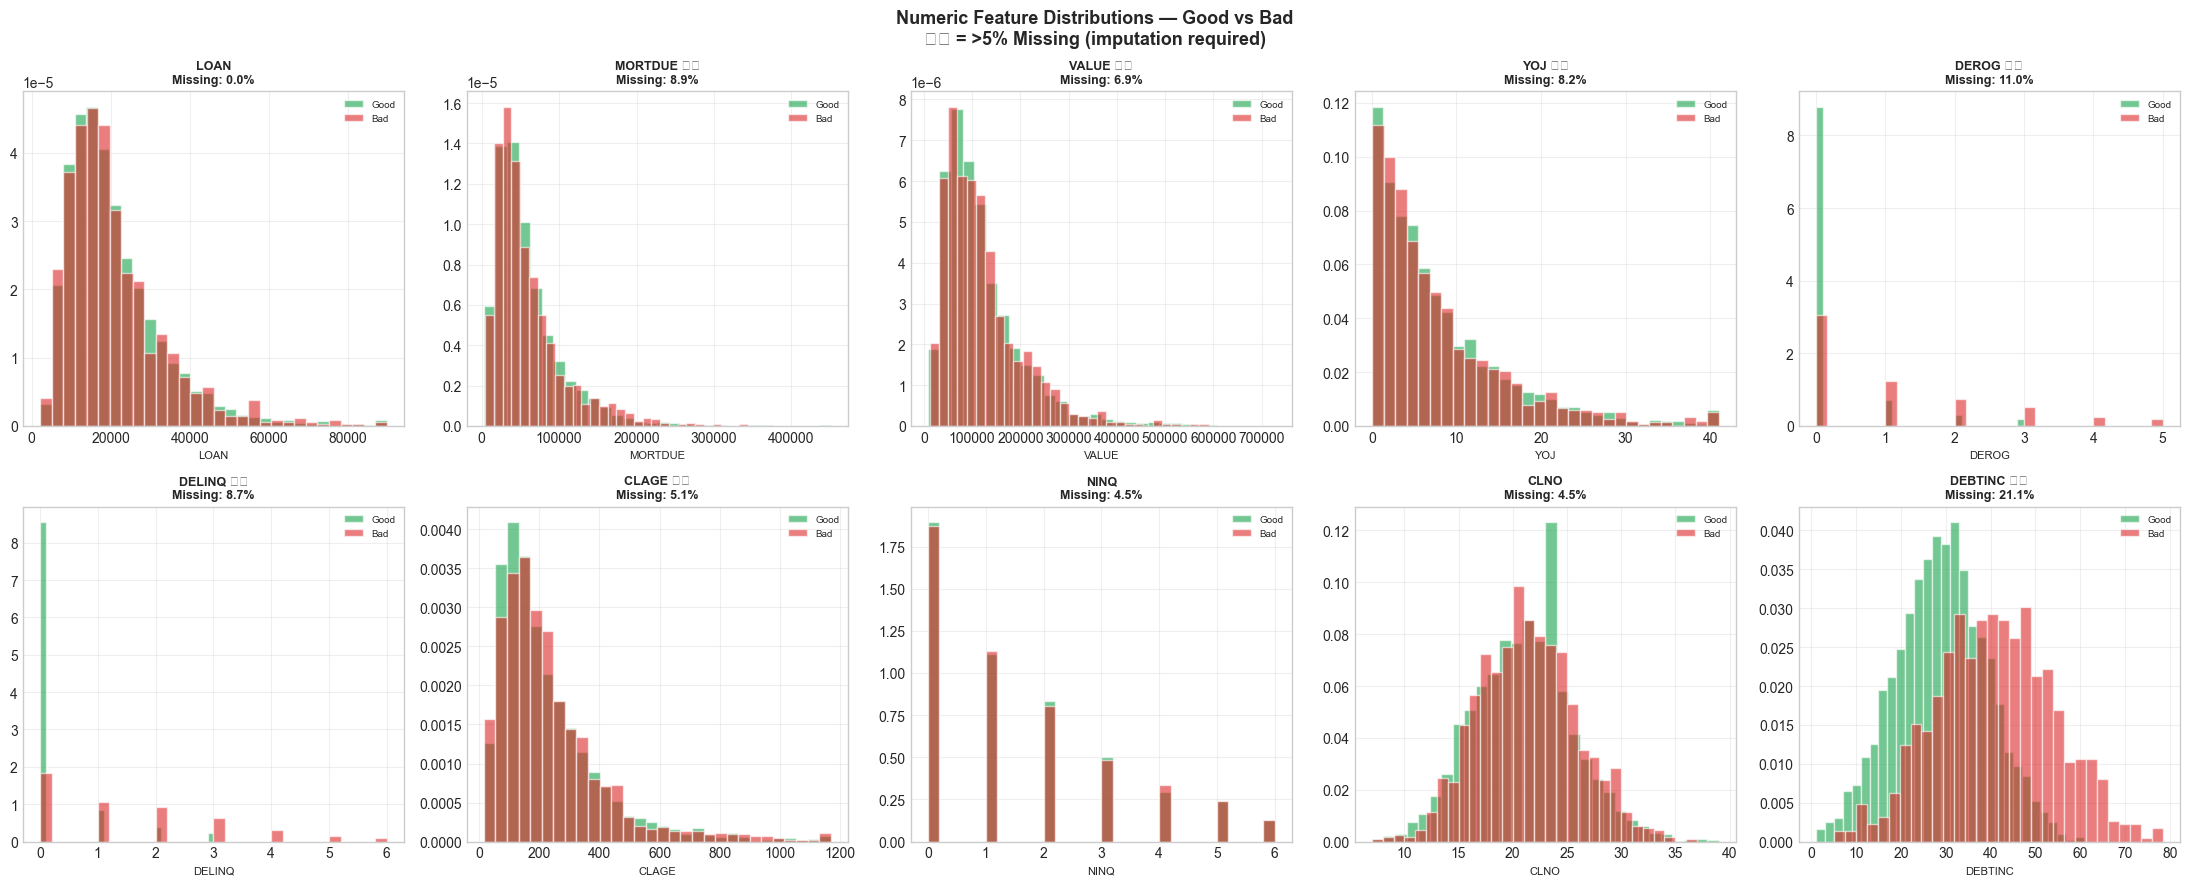

In [5]:
numeric_cols = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG",
                "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax   = axes[i]
    good = df.loc[df["BAD"]==0, col].dropna()
    bad  = df.loc[df["BAD"]==1, col].dropna()
    ax.hist(good, bins=30, alpha=0.60, color=GREEN, density=True, label="Good", edgecolor="white")
    ax.hist(bad,  bins=30, alpha=0.60, color=RED,   density=True, label="Bad",  edgecolor="white")

    miss_pct = df[col].isna().mean()*100
    flag = " ⚠️" if miss_pct > 5 else ""
    ax.set_title(f"{col}{flag}\nMissing: {miss_pct:.1f}%", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_xlabel(col, fontsize=8)

plt.suptitle("Numeric Feature Distributions — Good vs Bad\n"
             "⚠️ = >5% Missing (imputation required)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/01_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Correlation Analysis

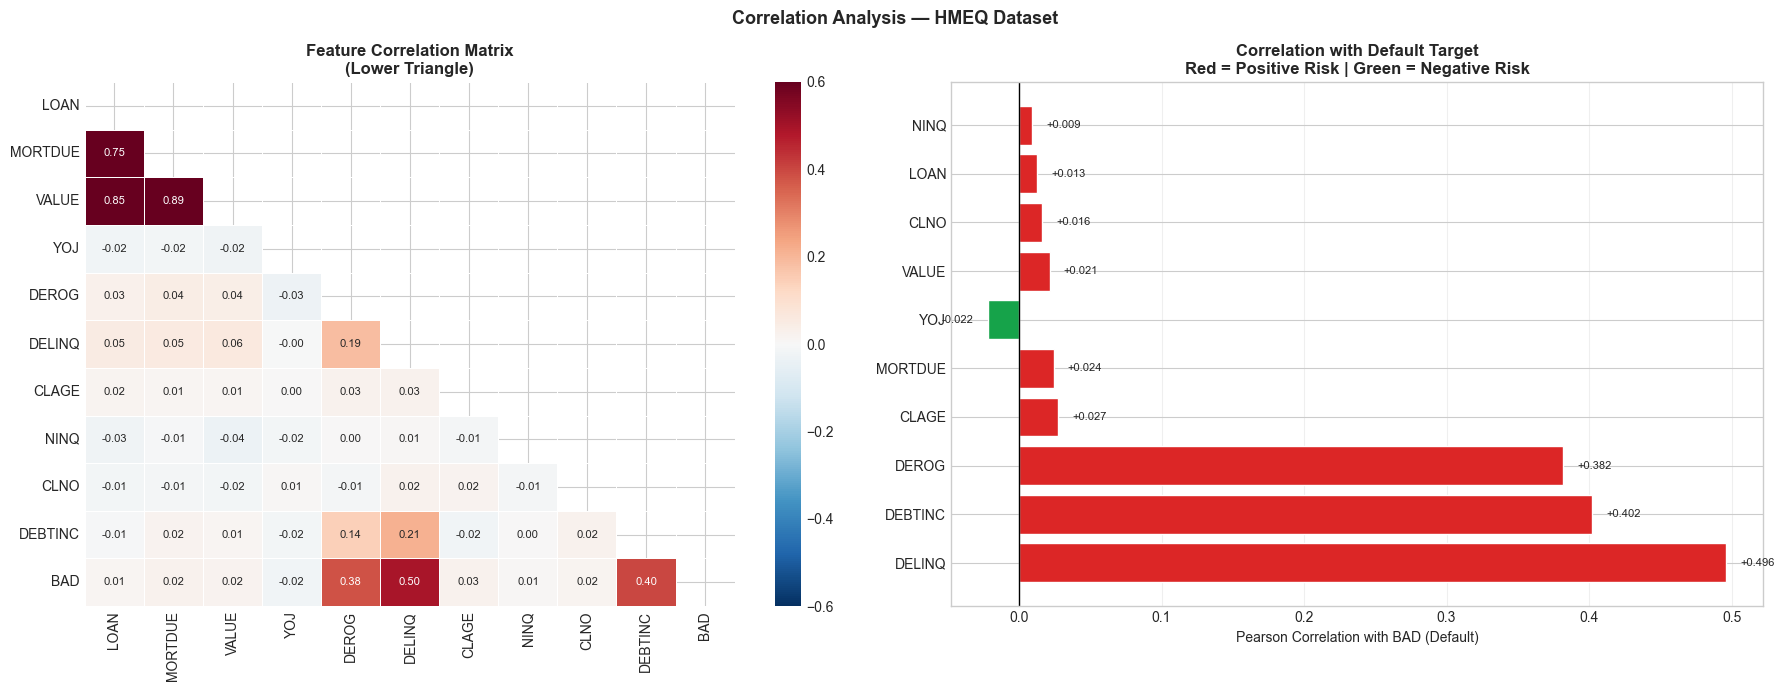


Top 5 predictors (by |correlation| with default):
  DELINQ      : r=+0.4964  ↑ Higher = more risk
  DEBTINC     : r=+0.4021  ↑ Higher = more risk
  DEROG       : r=+0.3816  ↑ Higher = more risk
  CLAGE       : r=+0.0272  ↑ Higher = more risk
  MORTDUE     : r=+0.0243  ↑ Higher = more risk


In [6]:
corr_df = df[numeric_cols + ["BAD"]].dropna()
corr    = corr_df.corr()
corr_target = corr["BAD"].drop("BAD").sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], linewidths=0.5, annot_kws={"size":8},
            vmin=-0.6, vmax=0.6)
axes[0].set_title("Feature Correlation Matrix\n(Lower Triangle)", fontweight="bold")

# Correlation with target
bar_colors = [RED if v > 0 else GREEN for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
for i, (feat, val) in enumerate(corr_target.items()):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                  f"{val:+.3f}", va="center", fontsize=8,
                  ha="left" if val >= 0 else "right")
axes[1].set_xlabel("Pearson Correlation with BAD (Default)")
axes[1].set_title("Correlation with Default Target\n"
                   "Red = Positive Risk | Green = Negative Risk", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Correlation Analysis — HMEQ Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/01_correlation_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 predictors (by |correlation| with default):")
for feat, val in corr_target.head(5).items():
    direction = "↑ Higher = more risk" if val > 0 else "↓ Lower = more risk"
    print(f"  {feat:<12}: r={val:+.4f}  {direction}")

## 5. Categorical Feature Analysis

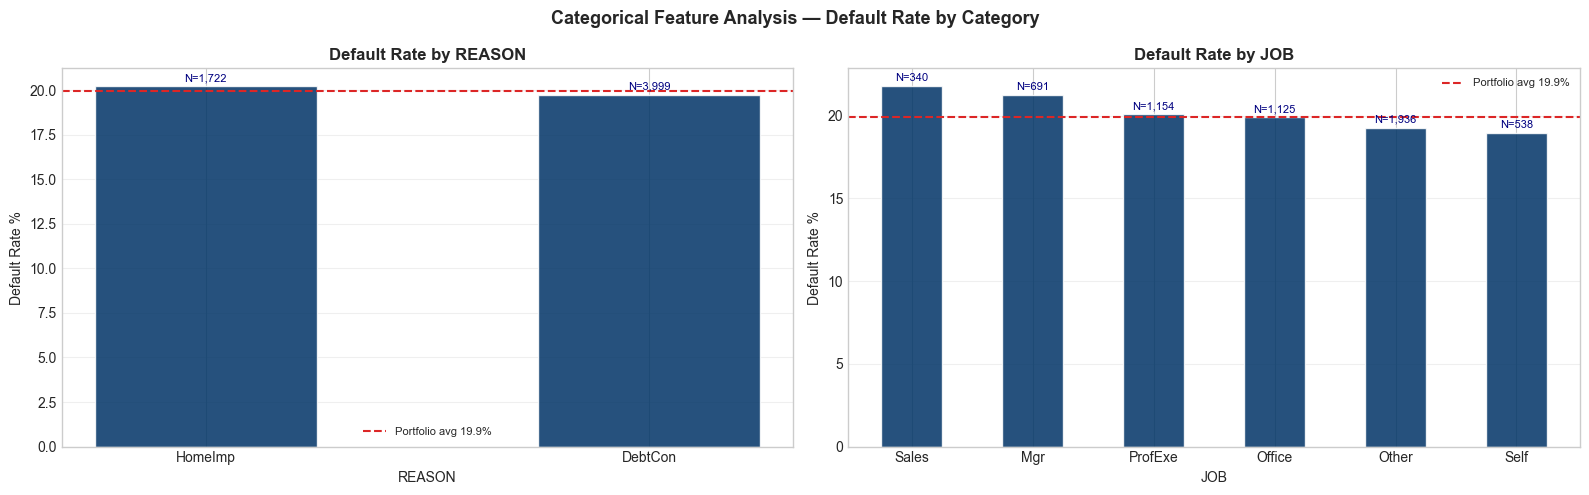

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, ["REASON", "JOB"]):
    stats = (df.groupby(col)["BAD"]
               .agg(DefaultRate="mean", N="count")
               .reset_index()
               .sort_values("DefaultRate", ascending=False))
    bars  = ax.bar(stats[col], stats["DefaultRate"]*100,
                    color=NAVY, edgecolor="white", alpha=0.85, width=0.5)
    for bar, row in zip(bars, stats.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"N={row.N:,}", ha="center", fontsize=8, color="navy")
    ax.axhline(default_rate*100, color=RED, ls="--", lw=1.5,
               label=f"Portfolio avg {default_rate:.1%}")
    ax.set_ylabel("Default Rate %"); ax.set_xlabel(col)
    ax.set_title(f"Default Rate by {col}", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Categorical Feature Analysis — Default Rate by Category",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/01_categorical_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. DEBTINC — Key Canadian Risk Driver (OSFI B-20 Alignment)

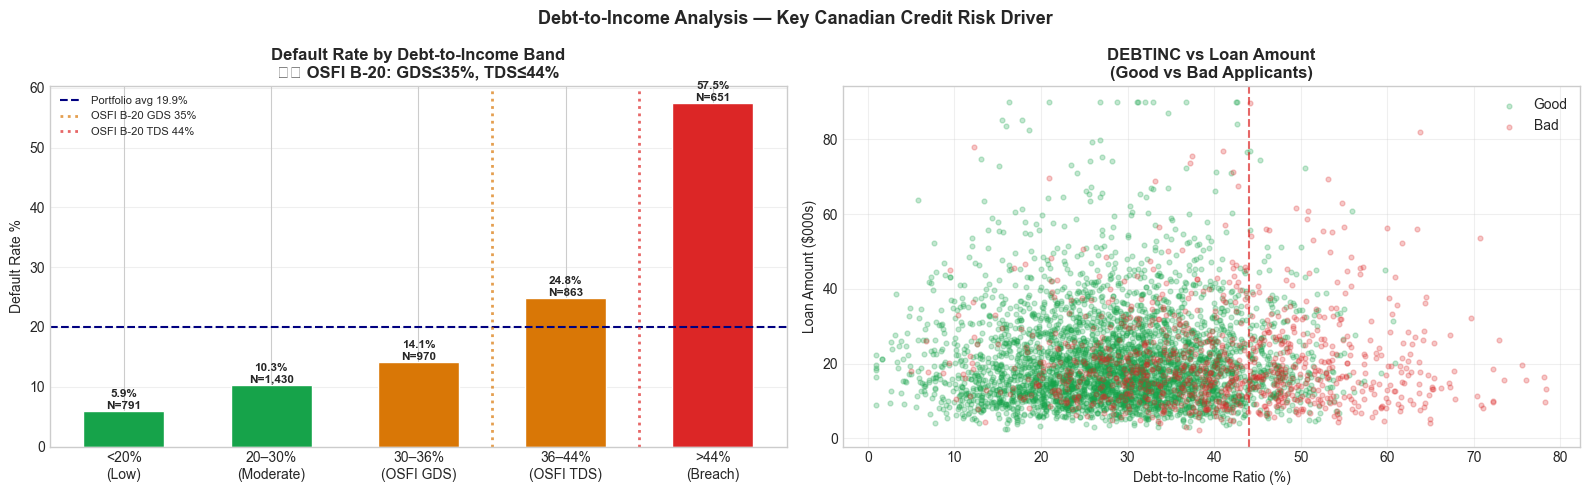

In [8]:
df_dti = df[df["DEBTINC"].notna()].copy()
df_dti["DTI_Band"] = pd.cut(df_dti["DEBTINC"],
                              bins=[0, 20, 30, 36, 44, 200],
                              labels=["<20%\n(Low)", "20–30%\n(Moderate)",
                                       "30–36%\n(OSFI GDS)", "36–44%\n(OSFI TDS)",
                                       ">44%\n(Breach)"])
dti_stats = df_dti.groupby("DTI_Band")["BAD"].agg(["mean","count"]).reset_index()
band_colors = [GREEN, GREEN, AMBER, AMBER, RED]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bars = axes[0].bar(dti_stats["DTI_Band"], dti_stats["mean"]*100,
                    color=band_colors, edgecolor="white", width=0.55)
for bar, row in zip(bars, dti_stats.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                  f"{row.mean:.1%}\nN={row.count:,}", ha="center",
                  fontsize=8.5, fontweight="bold")
axes[0].axhline(default_rate*100, color="navy", ls="--", lw=1.5,
                 label=f"Portfolio avg {default_rate:.1%}")
axes[0].axvline(2.5, color=AMBER, ls=":", lw=2, alpha=0.7, label="OSFI B-20 GDS 35%")
axes[0].axvline(3.5, color=RED,   ls=":", lw=2, alpha=0.7, label="OSFI B-20 TDS 44%")
axes[0].set_ylabel("Default Rate %")
axes[0].set_title("Default Rate by Debt-to-Income Band\n⚠️ OSFI B-20: GDS≤35%, TDS≤44%",
                   fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)

# DEBTINC scatter vs LOAN
scatter_df = df[["DEBTINC","LOAN","BAD"]].dropna()
for bad_val, color, label in [(0, GREEN, "Good"), (1, RED, "Bad")]:
    mask = scatter_df["BAD"] == bad_val
    axes[1].scatter(scatter_df.loc[mask,"DEBTINC"], scatter_df.loc[mask,"LOAN"]/1000,
                     alpha=0.25, c=color, s=12, label=label)
axes[1].set_xlabel("Debt-to-Income Ratio (%)")
axes[1].set_ylabel("Loan Amount ($000s)")
axes[1].set_title("DEBTINC vs Loan Amount\n(Good vs Bad Applicants)", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].axvline(44, color=RED, ls="--", lw=1.5, alpha=0.7, label="OSFI TDS 44%")

plt.suptitle("Debt-to-Income Analysis — Key Canadian Credit Risk Driver",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/01_debtinc_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Derogatory & Delinquency Severity Analysis

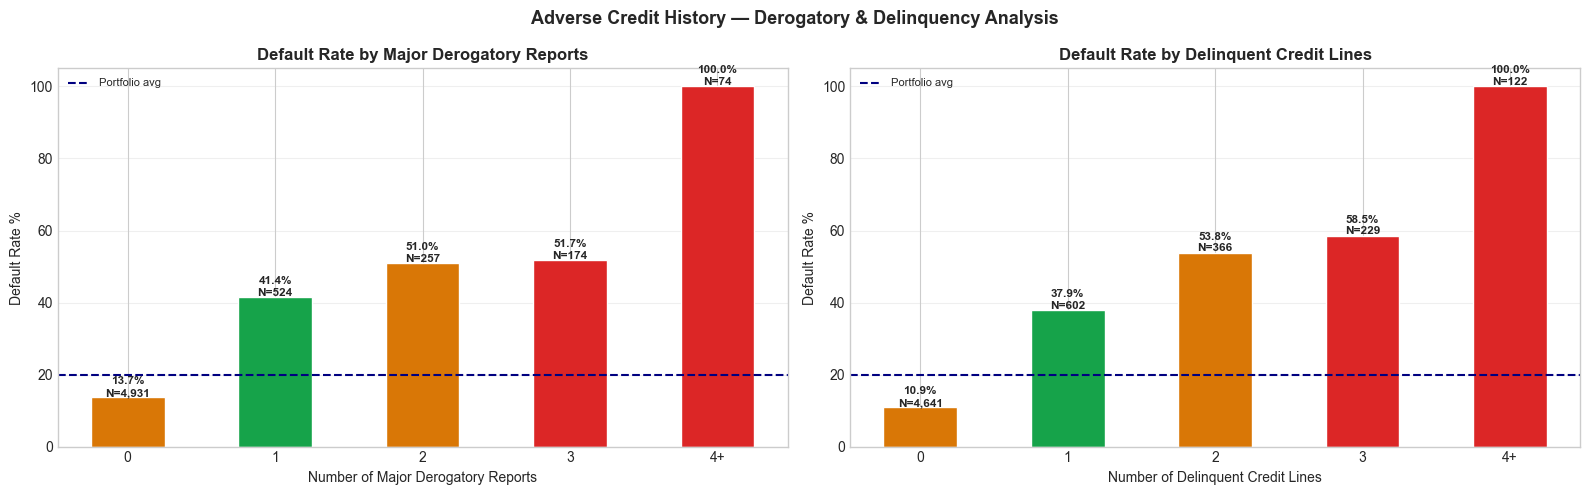

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title in [
    (axes[0], "DEROG",  "Major Derogatory Reports"),
    (axes[1], "DELINQ", "Delinquent Credit Lines"),
]:
    vc = df[col].fillna(-1).clip(0, 4).astype(int).map(
        {-1:"Missing",0:"0",1:"1",2:"2",3:"3",4:"4+"})
    vc_stats = df.copy()
    vc_stats[col+"_BIN"] = df[col].fillna(-1).clip(0,4).astype(int)
    stats = vc_stats.groupby(col+"_BIN")["BAD"].agg(["mean","count"]).reset_index()
    colors_bar = [AMBER] + [GREEN] + [AMBER, RED, RED, RED]
    bars = ax.bar(stats[col+"_BIN"].astype(str).replace({"-1":"Missing","4":"4+"}),
                   stats["mean"]*100,
                   color=colors_bar[:len(stats)], edgecolor="white", width=0.5)
    for bar, row in zip(bars, stats.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{row.mean:.1%}\nN={row.count:,}", ha="center", fontsize=8.5, fontweight="bold")
    ax.axhline(default_rate*100, color="navy", ls="--", lw=1.5, label=f"Portfolio avg")
    ax.set_ylabel("Default Rate %"); ax.set_xlabel(f"Number of {title}")
    ax.set_title(f"Default Rate by {title}", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Adverse Credit History — Derogatory & Delinquency Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/01_adverse_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary Statistics Table

In [10]:
print("\n" + "="*70)
print("  EDA SUMMARY — KEY FINDINGS FOR SCORECARD DEVELOPMENT")
print("="*70)
summary = {
    "DEBTINC": f"Strongest predictor. OSFI B-20 breach (>44%) → {df[df['DEBTINC']>44]['BAD'].mean():.0%} default rate",
    "DEROG":   f"Any derogatory report → {df[df['DEROG']>0]['BAD'].mean():.0%} default vs {df[df['DEROG']==0]['BAD'].mean():.0%} clean",
    "DELINQ":  f"Any delinquency → {df[df['DELINQ']>0]['BAD'].mean():.0%} default vs {df[df['DELINQ']==0]['BAD'].mean():.0%} clean",
    "YOJ":     f"Missing in {df['YOJ'].isna().mean():.0%} — add missing indicator flag",
    "VALUE":   f"Property value. Missing in {df['VALUE'].isna().mean():.0%} — use LTV proxy",
    "CLAGE":   f"Credit age. Longer history → lower risk. Missing in {df['CLAGE'].isna().mean():.0%}",
    "NINQ":    f"Recent inquiries — inverse signal (shopping for credit = risk)",
}
for k, v in summary.items():
    print(f"  {k:<10} {v}")
print("="*70)
print(f"\n EDA complete. Charts saved to reports/output/")
print(f"   Next step → Run notebook 02_Feature_Engineering_WoE.py")


  EDA SUMMARY — KEY FINDINGS FOR SCORECARD DEVELOPMENT
  DEBTINC    Strongest predictor. OSFI B-20 breach (>44%) → 57% default rate
  DEROG      Any derogatory report → 50% default vs 12% clean
  DELINQ     Any delinquency → 52% default vs 10% clean
  YOJ        Missing in 8% — add missing indicator flag
  VALUE      Property value. Missing in 7% — use LTV proxy
  CLAGE      Credit age. Longer history → lower risk. Missing in 5%
  NINQ       Recent inquiries — inverse signal (shopping for credit = risk)

 EDA complete. Charts saved to reports/output/
   Next step → Run notebook 02_Feature_Engineering_WoE.py
